## Shot Visualizer

In [1]:
# 🏀 NBA Shot Map Visualizer (2020–2025)
# Combines draw_shot_chart.py, shotchart.py, and main.py

# ---- Imports ----
import os
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
from matplotlib.colors import LogNorm
from nba_api.stats.static import players, teams
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.endpoints import leaguedashplayerstats
from sklearn.preprocessing import MinMaxScaler
import re
# ---- Court Drawing ----
def create_court(ax, color):
    ax.plot([-220, -220], [0, 140], linewidth=2, color=color)
    ax.plot([220, 220], [0, 140], linewidth=2, color=color)
    ax.add_artist(mpl.patches.Arc((0, 140), 440, 315, theta1=0, theta2=180, facecolor='none', edgecolor=color, lw=2))
    ax.plot([-80, -80], [0, 190], linewidth=2, color=color)
    ax.plot([80, 80], [0, 190], linewidth=2, color=color)
    ax.plot([-60, -60], [0, 190], linewidth=2, color=color)
    ax.plot([60, 60], [0, 190], linewidth=2, color=color)
    ax.plot([-80, 80], [190, 190], linewidth=2, color=color)
    ax.add_artist(mpl.patches.Circle((0, 190), 60, facecolor='none', edgecolor=color, lw=2))
    ax.add_artist(mpl.patches.Circle((0, 60), 15, facecolor='none', edgecolor=color, lw=2))
    ax.plot([-30, 30], [40, 40], linewidth=2, color=color)
    ax.set_xlim(-250, 250)
    ax.set_ylim(0, 470)
    ax.set_xticks([])
    ax.set_yticks([])
    mpl.rcParams['font.family'] = 'Avenir'
    mpl.rcParams['font.size'] = 14
    mpl.rcParams['axes.linewidth'] = 2

def draw_shots(ax, df):
    made_shots = df[df['SHOT_MADE_FLAG'] == 1]
    missed_shots = df[df['SHOT_MADE_FLAG'] == 0]
    ax.scatter(made_shots['LOC_X'], made_shots['LOC_Y'] + 60, c='lime', s=10, alpha=0.7, label="Made")
    ax.scatter(missed_shots['LOC_X'], missed_shots['LOC_Y'] + 60, c='red', s=10, alpha=0.5, label="Missed")

def draw_shots_hex(ax, df, gridsize=25, mincount=10):
    x = df["LOC_X"].to_numpy()
    y = (df["LOC_Y"] + 60).to_numpy()
    hb = ax.hexbin(
        x, y, gridsize=gridsize, extent=[-250, 250, 0, 470],
        mincnt=mincount, linewidths=0, cmap='plasma', norm=LogNorm()
    )
    return hb

# ---- Data Retrieval ----
all_teams = teams.get_teams()
player_dict = [p for p in players.get_players() if p["is_active"]]

def get_shot_data_team(team_nickname, year):
    team_info = [team for team in all_teams if team['nickname'] == team_nickname][0]
    team_id = team_info['id']
    team_shotlog = shotchartdetail.ShotChartDetail(
        team_id=team_id, player_id=0,
        context_measure_simple='FGA',
        season_nullable=f"{year}-{str(year+1)[-2:]}",
        season_type_all_star=['Regular Season']
    ).get_data_frames()[0]
    return team_shotlog

def get_shot_data_player(player_full_name, season="2024-25"):
    player_info = [p for p in player_dict if p['full_name'] == player_full_name][0]
    player_id = player_info['id']
    print(f"Fetching shot data for {player_full_name} ({player_id}) ...")
    player_shotlog = shotchartdetail.ShotChartDetail(
        team_id=0, player_id=player_id,
        context_measure_simple='FGA',
        season_nullable=season,
        season_type_all_star=['Regular Season', 'Playoffs']
    ).get_data_frames()[0]
    return player_shotlog

# ---- Multi-Year Fetch ----
def fetch_year(YEAR):
    if not (2020 <= YEAR <= 2025):
        raise ValueError("YEAR must be between 2020–2025")
    dfs = []
    for team in all_teams:
        print(f"Fetching {team['nickname']} ({YEAR}) ...")
        new_df = get_shot_data_team(team["nickname"], YEAR)
        dfs.append(new_df)
        time.sleep(0.5)
    master_df = pd.concat(dfs, ignore_index=True)
    os.makedirs("years", exist_ok=True)
    master_df.to_csv(f"./years/{YEAR}.csv", index=False)
    print(f"✅ Saved ./years/{YEAR}.csv")

# ---- Visualization ----
def draw_player_shot_chart(player_name, season="2024-25"):
    df = get_shot_data_player(player_name, season)
    fig, ax = plt.subplots(figsize=(7, 6.8))
    ax.set_facecolor("black")
    draw_shots(ax, df)
    create_court(ax, 'white')
    ax.legend()
    ax.set_title(f"{player_name} | {season}", color="white")
    plt.show()

def draw_league_shot_chart(YEAR):
    if not os.path.exists(f"./years/{YEAR}.csv"):
        fetch_year(YEAR)
    df = pd.read_csv(f"./years/{YEAR}.csv")
    fig, ax = plt.subplots(figsize=(7, 6.8))
    ax.set_facecolor("black")
    hb = draw_shots_hex(ax, df, gridsize=35, mincount=0)
    create_court(ax, 'white')
    fig.colorbar(hb, ax=ax, label="Shot Density")
    ax.set_title(f"NBA League Shot Density | {YEAR}", color="white")
    plt.show()

# ---- Example Run ----
# Draw for one player:
# draw_player_shot_chart("Stephen Curry", "2024-25")

# Or visualize a league shot heatmap for a specific year:
#draw_league_shot_chart(2021)

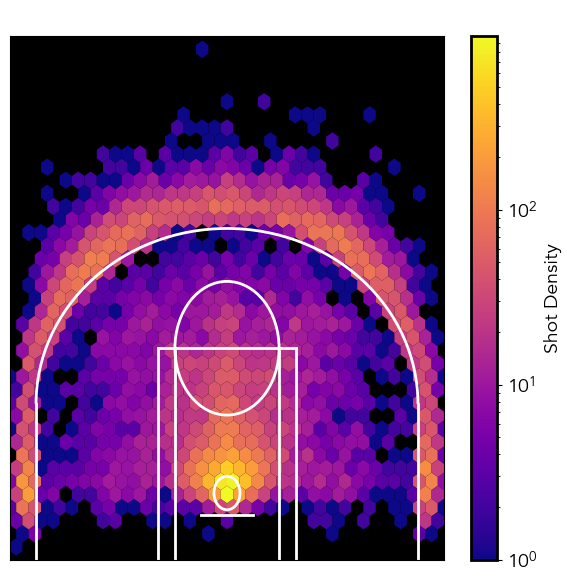

In [2]:
draw_league_shot_chart(2025)

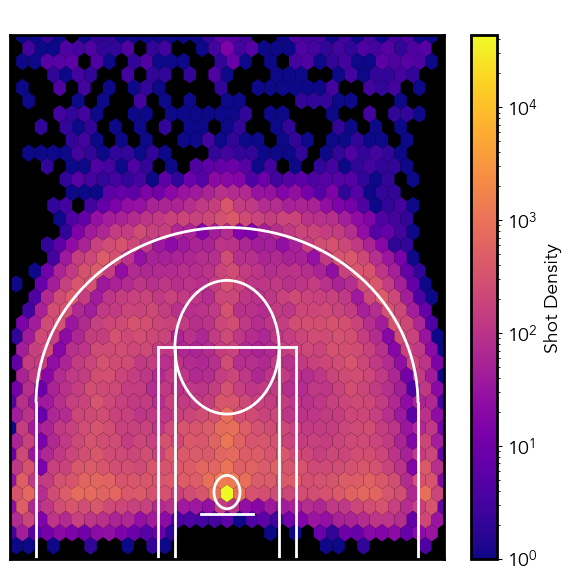

In [3]:
draw_league_shot_chart(2000)

Fetching shot data for Shai Gilgeous-Alexander (1628983) ...


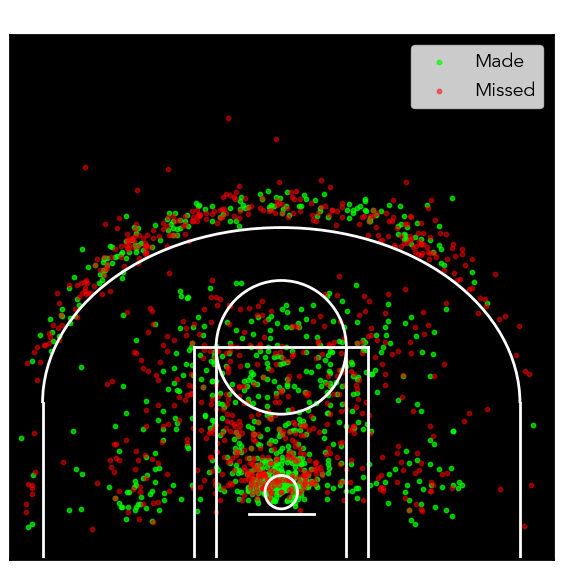

In [4]:
draw_player_shot_chart("Shai Gilgeous-Alexander", "2024-25")

Notes:
- An efficiency map?


## Efficiency score

In [5]:
#Basic efficiency calculator
def get_player_eFG(player_full_name, season="2024-25"):
    df = get_shot_data_player(player_full_name)

    if df.empty:
        raise ValueError("No shot data for player.")

    FGM = df["SHOT_MADE_FLAG"].sum()
    FGA = df["SHOT_ATTEMPTED_FLAG"].sum()

    # Identify 3PT makes
    df["IS_THREE"] = df["SHOT_TYPE"].str.contains("3PT")
    three_pm = df[(df["SHOT_MADE_FLAG"] == 1) & (df["IS_THREE"])].shape[0]

    eFG = (FGM + 0.5 * three_pm) / FGA

    return {
        "player": player_full_name,
        "season": season,
        "FGA": int(FGA),
        "FGM": int(FGM),
        "3PM": int(three_pm),
        "eFG%": np.round(float(eFG), 2)
    }

In [6]:
get_player_eFG("Stephen Curry", "2024-25")

Fetching shot data for Stephen Curry (201939) ...


{'player': 'Stephen Curry',
 'season': '2024-25',
 'FGA': 1258,
 'FGM': 564,
 '3PM': 311,
 'eFG%': 0.57}

In [7]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

def load_pbp_2020_2024():
    dataset = "brains14482/nba-playbyplay-and-shotdetails-data-19962021"
    dfs = []
    
    for year in range(2020, 2025):
        filename = f"cdnnba_{year}.csv"
        print(f"Loading {filename}...")

        try:
            df_year = kagglehub.load_dataset(
                KaggleDatasetAdapter.PANDAS,
                dataset,
                filename
            )
            df_year["season"] = year   # add season column for clarity
            dfs.append(df_year)
        except Exception as e:
            print(f"⚠️ Could not load {filename}: {e}")
    
    if not dfs:
        raise ValueError("No files loaded — check filenames or dataset path.")
    
    big_df = pd.concat(dfs, ignore_index=True)
    print(f"\n✅ Loaded {len(dfs)} files.")
    print(f"📊 Total rows: {len(big_df):,}")
    return big_df


In [8]:
big_df = load_pbp_2020_2024()

Loading cdnnba_2020.csv...


/var/folders/h3/f3_68x516pj6d7h2119r5st00000gn/T/ipykernel_74932/2739384001.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_year = kagglehub.load_dataset(


Loading cdnnba_2021.csv...


/var/folders/h3/f3_68x516pj6d7h2119r5st00000gn/T/ipykernel_74932/2739384001.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_year = kagglehub.load_dataset(


Loading cdnnba_2022.csv...


...

Loading cdnnba_2023.csv...


/var/folders/h3/f3_68x516pj6d7h2119r5st00000gn/T/ipykernel_74932/2739384001.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_year = kagglehub.load_dataset(


Loading cdnnba_2024.csv...


/var/folders/h3/f3_68x516pj6d7h2119r5st00000gn/T/ipykernel_74932/2739384001.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_year = kagglehub.load_dataset(



✅ Loaded 5 files.
📊 Total rows: 3,337,750


In [9]:
#big_df = pd.read_csv("nba_pbp_2020_2024.csv")

In [10]:
def _clock_to_seconds(clock_str: str) -> float:
    """
    Convert ISO-8601-ish clock like 'PT04M59.00S' to seconds remaining in period.
    Returns np.nan if unparsable.
    """
    if not isinstance(clock_str, str):
        return np.nan
    m = re.match(r"PT(?:(\d+)M)?(?:(\d+(?:\.\d+)?)S)?", clock_str)
    if not m:
        return np.nan
    mins = int(m.group(1) or 0)
    secs = float(m.group(2) or 0.0)
    return mins * 60 + secs

def prepare_clutch_df(df: pd.DataFrame) -> pd.DataFrame:
    """Precompute clutch-friendly columns in-place for repeated queries."""
    # Numeric casts
    for col in ["scoreHome", "scoreAway", "period"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Normalize text columns
    if "actionType" in df.columns:
        df["actionType"] = df["actionType"].astype(str).str.lower()
    else:
        df["actionType"] = ""

    if "shotResult" in df.columns:
        df["shotResult"] = df["shotResult"].astype(str).str.lower()
    else:
        df["shotResult"] = ""

    df["isFieldGoal"] = pd.to_numeric(df.get("isFieldGoal", 0), errors="coerce").fillna(0).astype(int)

    if "playerName" in df.columns:
        df["_playerName_lower"] = df["playerName"].astype(str).str.lower().str.strip()
    if "playerNameI" in df.columns:
        df["_playerNameI_lower"] = df["playerNameI"].astype(str).str.lower().str.strip()

    if "clock" not in df.columns:
        raise ValueError("Expected 'clock' column not found.")
    df["_clock_s"] = df["clock"].apply(_clock_to_seconds)
    df["_score_diff"] = (df["scoreHome"] - df["scoreAway"]).abs()

    df["_is_shot"] = df["actionType"].isin({"2pt", "3pt"}) & (df["isFieldGoal"] == 1)
    df["_is_clutch"] = (df["period"] >= 4) & (df["_clock_s"] <= 300) & (df["_score_diff"] <= 10)

    return df

def _player_mask(df: pd.DataFrame, player_full_name: str, player_person_id: int | None = None):
    """
    Match player rows in the Kaggle play-by-play dataset.
    - dataset stores last names in `playerName` and initial+last in `playerNameI`
    - optionally pass player_person_id to avoid mixing players who share a last name (e.g., S. Curry)
    Returns (mask, note).
    """
    if not player_full_name or not str(player_full_name).strip():
        raise ValueError("player_full_name is required.")

    name = str(player_full_name).strip()
    parts = name.split()
    first = parts[0]
    last = parts[-1]

    variants = {name.lower(), last.lower()}
    if first:
        variants.add(f"{first[0].lower()}. {last.lower()}")

    name_col = df["_playerName_lower"] if "_playerName_lower" in df.columns else df.get("playerName", pd.Series([], dtype=str)).astype(str).str.lower().str.strip()
    namei_col = df["_playerNameI_lower"] if "_playerNameI_lower" in df.columns else df.get("playerNameI", pd.Series([], dtype=str)).astype(str).str.lower().str.strip()

    mask = name_col.eq(last.lower()) | namei_col.isin(variants)
    note = None

    if "personId" in df.columns:
        if player_person_id is not None:
            mask = mask & (df["personId"] == player_person_id)
        else:
            person_ids = df.loc[mask, "personId"].dropna().astype(int)
            if person_ids.empty:
                note = "No personId rows matched those name variants."
            else:
                counts = person_ids.value_counts()
                top_id = counts.idxmax()
                if counts.size > 1:
                    note = f"Matched multiple playerIds {counts.index.tolist()} — using most frequent {top_id}. Pass player_person_id to override."
                mask = mask & (df["personId"] == top_id)

    return mask, note

def get_player_eFG_clutch(big_df: pd.DataFrame, player_full_name: str, seasons: list[int] | None = None, player_person_id: int | None = None):
    """
    eFG% during clutch only:
      - last 5:00 of period
      - abs(scoreHome - scoreAway) <= 10
      - period >= 4 (4th + any OT)
    Optionally filter to specific numeric seasons (e.g., [2020,2021,...]).
    Pass player_person_id to disambiguate players with the same last name.
    Assumes prepare_clutch_df(df) has already been run.
    """
    df = big_df

    if "_is_shot" not in df.columns or "_is_clutch" not in df.columns:
        raise ValueError("Call prepare_clutch_df(df) once before querying clutch stats.")

    player_mask, note = _player_mask(df, player_full_name, player_person_id)

    mask = df["_is_shot"] & df["_is_clutch"] & player_mask

    if seasons is not None:
        mask = mask & df["season"].isin(seasons)

    clutch_shots = df[mask]

    if clutch_shots.empty:
        return {
            "player": player_full_name,
            "seasons": seasons or "all in big_df",
            "FGA": 0, "FGM": 0, "3PM": 0, "eFG%": np.nan,
            "note": note or "No clutch shot attempts found with the given filters."
        }

    FGA = len(clutch_shots)
    FGM = (clutch_shots["shotResult"] == "made").sum()
    three_pm = ((clutch_shots["actionType"] == "3pt") & (clutch_shots["shotResult"] == "made")).sum()

    eFG = (FGM + 0.5 * three_pm) / FGA if FGA > 0 else np.nan

    return {
        "player": player_full_name,
        "seasons": seasons or "all in big_df",
        "FGA": int(FGA),
        "FGM": int(FGM),
        "3PM": int(three_pm),
        "eFG%": float(np.round(eFG, 3)),
        "note": note,
    }


In [11]:
# Precompute clutch columns once after loading/concatenating big_df
prepare_clutch_df(big_df)


,actionNumber,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,...,areaDetail,isTargetScoreLastPeriod,shortFormattedClock,jerseyNumber,_playerName_lower,_playerNameI_lower,_clock_s,_score_diff,_is_shot,_is_clutch
0,2,PT12M00.00S,2020-12-23T00:06:19Z,1,REGULAR,period,start,NaN,0,NaN,...,NaN,NaN,NaN,NaN,nan,nan,720.0,0,False,False
1,4,PT11M58.00S,2020-12-23T00:06:25.200Z,1,REGULAR,jumpball,recovered,NaN,0,NaN,...,NaN,NaN,NaN,NaN,nan,nan,718.0,0,False,False
2,7,PT11M50.00S,2020-12-23T00:06:46Z,1,REGULAR,turnover,out-of-bounds,NaN,201599,NaN,...,NaN,NaN,NaN,NaN,jordan,d. jordan,710.0,0,False,False
3,8,PT11M38.00S,2020-12-23T00:07:04.400Z,1,REGULAR,foul,personal,2freethrow,202681,NaN,...,NaN,NaN,NaN,NaN,irving,k. irving,698.0,0,False,False
4,10,PT11M38.00S,2020-12-23T00:07:26Z,1,REGULAR,freethrow,1 of 2,fromturnover,201939,NaN,...,NaN,NaN,NaN,NaN,curry,s. curry,698.0,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3337745,723,PT00M05.00S,2024-12-15T04:14:59.100Z,4,REGULAR,freethrow,2 of 2,NaN,1628983,NaN,...,NaN,False,NaN,NaN,gilgeous-alexander,s. gilgeous-alexander,5.0,15,False,False
3337746,724,PT00M00.00S,2024-12-15T04:15:11.200Z,4,REGULAR,3pt,Jump Shot,NaN,1630224,19.661629,...,24+ Left Center,False,NaN,NaN,green,j. green,0.0,15,True,False
3337747,725,PT00M00.00S,2024-12-15T04:15:13.500Z,4,REGULAR,rebound,offensive,team,0,NaN,...,24+ Left Center,False,NaN,NaN,nan,nan,0.0,15,False,False
3337748,726,PT00M00.00S,2024-12-15T04:15:28Z,4,REGULAR,period,end,NaN,0,NaN,...,NaN,False,NaN,NaN,nan,nan,0.0,15,False,False


In [12]:
get_player_eFG_clutch(big_df, "Stephen Curry", seasons=[2020, 2021, 2022, 2023, 2024])

{'player': 'Stephen Curry',
 'seasons': [2020, 2021, 2022, 2023, 2024],
 'FGA': 680,
 'FGM': 286,
 '3PM': 144,
 'eFG%': 0.526,
 'note': 'Matched multiple playerIds [201939, 203552] — using most frequent 201939. Pass player_person_id to override.'}

In [13]:
get_player_eFG_clutch(big_df, "Luka Doncic", seasons=[2022, 2023, 2024])


{'player': 'Luka Doncic',
 'seasons': [2022, 2023, 2024],
 'FGA': 219,
 'FGM': 102,
 '3PM': 30,
 'eFG%': 0.534,
 'note': None}

In [14]:
get_player_eFG_clutch(big_df, "LeBron James", seasons=[2020, 2021, 2022, 2023, 2024])


{'player': 'LeBron James',
 'seasons': [2020, 2021, 2022, 2023, 2024],
 'FGA': 532,
 'FGM': 249,
 '3PM': 65,
 'eFG%': 0.529,
 'note': 'Matched multiple playerIds [2544, 1629713, 1628455, 1642355] — using most frequent 2544. Pass player_person_id to override.'}

In [15]:
get_player_eFG_clutch(big_df, "Kyrie Irving", seasons=[2020, 2021, 2022, 2023, 2024])

{'player': 'Kyrie Irving',
 'seasons': [2020, 2021, 2022, 2023, 2024],
 'FGA': 444,
 'FGM': 212,
 '3PM': 69,
 'eFG%': 0.555,
 'note': None}

In [16]:
get_player_eFG_clutch(big_df, 'Luka Doncic', seasons=[2020, 2021, 2022, 2023, 2024], player_person_id=1629029)

{'player': 'Luka Doncic',
 'seasons': [2020, 2021, 2022, 2023, 2024],
 'FGA': 442,
 'FGM': 197,
 '3PM': 54,
 'eFG%': 0.507,
 'note': None}